# Kooman Method Data Availability
This notebook investigates if the currently available lock and chamber data provides enough information to implement the Kooman method for estimating lock capacity and traffic resistance.

**Reference Document:**\nThis analysis is based on the principles outlined in: [Lock capacity and traffic resistance of locks (C. Kooman, P.A. De Bruijn)](https://repository.tudelft.nl/record/uuid:2600fe7f-309a-4013-9d26-9d495b938bc1).\n\n**The Kooman Method Requires:**
- Chamber dimensions (Length, Width)
- Approach times, leveling times, door opening/closing times (or total locking time)
- Sill depths for maximum draft constraints


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the data
lock_df = gpd.read_parquet("../output/lock-schematization/lock.geoparquet")
chamber_df = gpd.read_parquet("../output/lock-schematization/chamber.geoparquet")
print(f"Loaded {len(lock_df)} locks and {len(chamber_df)} chambers.")

Loaded 1015 locks and 429 chambers.


## 1. Check Chamber Dimensions (Length & Width)

In [2]:
# Check how many chambers have length and width
has_dims = chamber_df["Length"].notnull() & chamber_df["Width"].notnull()
print(
    f"Chambers with Length and Width: {has_dims.sum()} / {len(chamber_df)} ({has_dims.mean():.1%})"
)

chamber_df[["Name", "Length", "Width"]].head()

Chambers with Length and Width: 385 / 429 (89.7%)


,Name,Length,Width
0,Sluiskolk Vlagtweddersluis,23.0,6.0
1,Sluiskolk sluis Bosscheveld,130.0,16.0
2,Sluiskolk Jan B. Bronssluis,28.8,6.0
3,Nieuwe kolk sluis Panheel,145.0,12.6
4,Oude kolk sluis Panheel,143.0,7.5


## 2. Check Timing Information
The Kooman method uses leveling time, entry/exit time, and door time. Let's see if we have `PassageDurationM` or similar metrics.

Chambers with PassageDurationM: 418 / 429 (97.4%)


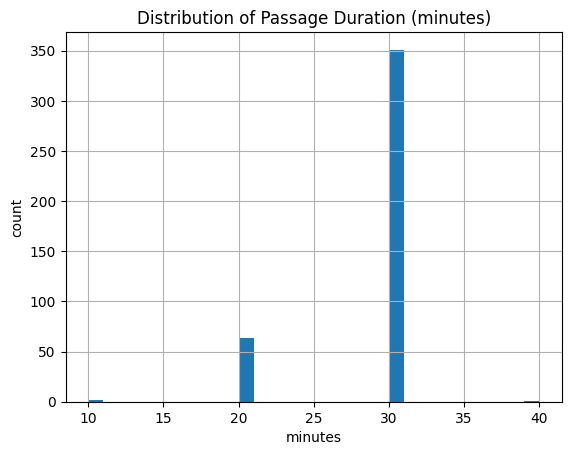

In [3]:
has_duration = (
    chamber_df["PassageDurationM"].notnull()
    if "PassageDurationM" in chamber_df.columns
    else pd.Series(False, index=chamber_df.index)
)
if has_duration.any():
    print(
        f"Chambers with PassageDurationM: {has_duration.sum()} / {len(chamber_df)} ({has_duration.mean():.1%})"
    )

    # Let's visualize the distribution of passage durations
    plt.figure()
    chamber_df["PassageDurationM"].hist(bins=30)
    plt.title("Distribution of Passage Duration (minutes)")
    plt.xlabel("minutes")
    plt.ylabel("count")
    plt.show()
else:
    print("No PassageDurationM column found.")

## 3. Check Sill Depths
Sill depth restricts the maximum draft of vessels entering the chamber.

In [4]:
# Identify sill depth columns
sill_cols = [c for c in chamber_df.columns if "Sill" in c]
print("Sill-related columns:", sill_cols)

# Check completeness
for col in sill_cols:
    completeness = chamber_df[col].notnull().mean()
    print(f"{col} completeness: {completeness:.1%}")

Sill-related columns: ['SillDepthBeBu', 'SillDepthBoBi', 'SillDepthInner']
SillDepthBeBu completeness: 91.4%
SillDepthBoBi completeness: 89.5%
SillDepthInner completeness: 7.7%


## 4. Case Study: Volkerak Sluizen
Let's zoom into a specific lock complex, the Volkeraksluizen (and the associated Jachtensluis). We'll evaluate if the data for these specific locks satisfies the Kooman method requirements.


In [5]:
volkerak_locks = lock_df[lock_df["Name"].str.contains("Volkerak", case=False, na=False)]
print("Found Volkerak Locks:")
display(volkerak_locks[["Id", "Name"]])

volkerak_chambers = chamber_df[chamber_df["ParentId"].isin(volkerak_locks["Id"])]
print(f"\nFound {len(volkerak_chambers)} chambers for Volkerak.")

# Select columns to display
cols_to_show = ["Name", "Length", "Width"]
if "PassageDurationM" in volkerak_chambers.columns:
    cols_to_show.append("PassageDurationM")
for col in sill_cols:
    if col in volkerak_chambers.columns:
        cols_to_show.append(col)

display(volkerak_chambers[cols_to_show])

Found Volkerak Locks:


,Id,Name
200,42863,Volkeraksluizen
243,52078,Jachtensluis Volkeraksluizen



Found 4 chambers for Volkerak.


,Name,Length,Width,PassageDurationM,SillDepthBeBu,SillDepthBoBi,SillDepthInner
227,Westkolk Volkeraksluizen,350.0,24.0,30.0,-6.25,-6.25,-6.2
228,Oostkolk Volkeraksluizen,331.5,24.1,30.0,-6.25,-6.25,NaN
229,Middenkolk Volkeraksluizen,329.0,24.1,30.0,-6.25,-6.25,-6.2
283,Sluiskolk Jachtensluis Volkeraksluizen,135.0,16.0,30.0,-6.25,-6.25,NaN


In [6]:
# Can we compute Kooman capacity?
# Capacity = (Vessels per locking) / (Total locking time)
# Typical Kooman method assumes:
# T_cycle = T_entry + T_exit + 2 * T_doors + 2 * T_leveling
# Here, we have PassageDurationM (average passage duration).
# We would need to estimate locking sub-components from this or fall back to external parameters.
print("We have the following basic metrics for Kooman for Volkerak:")
for _, row in volkerak_chambers.iterrows():
    print(
        f"- {row['Name']}: {row['Length']}m x {row['Width']}m, Passage Takes: {row.get('PassageDurationM', 'N/A')} mins"
    )

We have the following basic metrics for Kooman for Volkerak:
- Westkolk Volkeraksluizen: 350.0m x 24.0m, Passage Takes: 30.0 mins
- Oostkolk Volkeraksluizen: 331.5m x 24.1m, Passage Takes: 30.0 mins
- Middenkolk Volkeraksluizen: 329.0m x 24.1m, Passage Takes: 30.0 mins
- Sluiskolk Jachtensluis Volkeraksluizen: 135.0m x 16.0m, Passage Takes: 30.0 mins


## 5. Statistics of Other Locks (Excluding Volkerak)
Here we compute the overall statistics for all the other locks in the dataset, omitting the specific Volkerak Sluizen case study.

In [7]:
other_locks = lock_df[~lock_df["Name"].str.contains("Volkerak", case=False, na=False)]
other_chambers = chamber_df[chamber_df["ParentId"].isin(other_locks["Id"])]

print(f"Total other locks: {len(other_locks)}")
print(f"Total other chambers: {len(other_chambers)}")

# Length and Width stats
print("\nDimension Statistics (meters):")
display(other_chambers[["Length", "Width"]].describe().round(1))

# Passage Duration Stats
if "PassageDurationM" in other_chambers.columns:
    print("\nPassage Duration Statistics (minutes):")
    display(other_chambers[["PassageDurationM"]].describe().round(1))

# Sill Depth stats
if len(sill_cols) > 0:
    print("\nSill Depth Statistics (meters):")
    display(other_chambers[sill_cols].describe().round(1))

Total other locks: 1013
Total other chambers: 425

Dimension Statistics (meters):


,Length,Width
count,412.0,392.0
mean,81.3,11.0
std,79.1,7.6
min,10.0,2.4
25%,27.9,6.0
50%,50.0,8.5
75%,110.0,14.0
max,545.0,70.0



Passage Duration Statistics (minutes):


,PassageDurationM
count,414.0
mean,28.4
std,3.9
min,10.0
25%,30.0
50%,30.0
75%,30.0
max,40.0



Sill Depth Statistics (meters):


,SillDepthBeBu,SillDepthBoBi,SillDepthInner
count,388.0,380.0,31.0
mean,-1.8,-1.6,-2.6
std,3.2,3.3,4.3
min,-16.4,-14.5,-12.8
25%,-3.4,-3.4,-4.7
50%,-2.4,-2.4,-3.2
75%,-1.5,-1.3,-2.2
max,17.8,17.4,6.4


## 6. Overview of Locks on Hoofd Transport As (HTA) and Hoofdvaarwegen (HVW)
The main transport axes (HTA) and main fairways (HVW) are critical for inland navigation. We use `fairwayclassification.geoparquet` to identify locks located on these routes.

In [8]:
# Load fairway classification
fwc_df = gpd.read_parquet("../output/fis-export/fairwayclassification.geoparquet")

# Identify HTA and HVW fairways
hta_hvw_fwc = fwc_df[
    fwc_df["TypeDescription"].isin(["Hoofdtransportas", "Hoofdvaarweg"])
]

# Perform a spatial join between locks and these fairways
# We use a small buffer to ensure we capture locks that are exactly on the fairway boundary
locks_buffered = lock_df.copy()
locks_buffered["geometry"] = locks_buffered.geometry.buffer(10)

locks_hta_hvw = gpd.sjoin(
    locks_buffered,
    hta_hvw_fwc[["TypeDescription", "geometry"]],
    how="inner",
    predicate="intersects",
)
locks_hta_hvw = locks_hta_hvw.drop_duplicates(
    subset=["Id"]
)  # Drop duplicates from multiple fairway segments

print(f"Total Locks on HTA or HVW: {len(locks_hta_hvw)}")

print("\nBreakdown by Type:")
display(locks_hta_hvw["TypeDescription"].value_counts())

print("\nDetailed List of HTA/HVW Locks:")
# Get chamber info for these locks to provide more detail
hta_hvw_chambers = chamber_df[chamber_df["ParentId"].isin(locks_hta_hvw["Id"])]

# Merge chamber info with the lock names and types
merged_info = hta_hvw_chambers.merge(
    locks_hta_hvw[["Id", "Name", "TypeDescription"]],
    left_on="ParentId",
    right_on="Id",
    suffixes=("_chamber", "_lock"),
)

cols_to_show_hta = ["Name_lock", "TypeDescription", "Name_chamber", "Length", "Width"]
if "PassageDurationM" in merged_info.columns:
    cols_to_show_hta.append("PassageDurationM")

display(merged_info[cols_to_show_hta].sort_values(["TypeDescription", "Name_lock"]))

Total Locks on HTA or HVW: 1015



Breakdown by Type:


/var/folders/gr/0j917nfx62x487fv_l35dkn40000gn/T/ipykernel_24789/527075579.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  locks_buffered['geometry'] = locks_buffered.geometry.buffer(10)


TypeDescription
Hoofdtransportas    1011
Hoofdvaarweg           4
Name: count, dtype: int64


Detailed List of HTA/HVW Locks:


,Name_lock,TypeDescription,Name_chamber,Length,Width,PassageDurationM
166,1e Verlaat,Hoofdtransportas,Sluiskolk 1e Verlaat,36.1,11.3,30.0
46,2e Verlaat,Hoofdtransportas,Sluiskolk 2e verlaat,26.9,13.6,30.0
255,3e Verlaat of Buinerverlaat,Hoofdtransportas,Oude kolk 3e Verlaat of Buinerverlaat,24.2,10.6,30.0
256,3e Verlaat of Buinerverlaat,Hoofdtransportas,Nieuwe kolk 3e Verlaat of Buinerverlaat,42.0,6.0,30.0
8,4e Verlaat of 1e Musselverlaat,Hoofdtransportas,Nieuwe kolk 4e Verlaat of 1e Musselverlaat,30.0,11.9,30.0
...,...,...,...,...,...,...
318,Zuidersluis Hilversum,Hoofdtransportas,Sluiskolk Zuidersluis Hilversum,25.0,NaN,20.0
276,Zuidersluis IJmuiden,Hoofdtransportas,Grote kolk Zuidersluis IJmuiden,100.0,18.0,30.0
277,Zuidersluis IJmuiden,Hoofdtransportas,Kleine kolk Zuidersluis IJmuiden,111.0,NaN,30.0
31,Zuidersluis Nieuwegein,Hoofdtransportas,Sluiskolk Zuidersluis Nieuwegein,120.0,12.0,30.0


## 7. Grouping Locks by Lock Complexes (DISK)
Using the DISK dataset integration, we can group individual locks into lock complexes (`disk_complex_name`). This is useful for the Kooman method as multiple chambers in a single complex can share approach areas or influence each other's capacity.

In [9]:
# Merge chamber info with lock complex info
chamber_complex_df = chamber_df.merge(
    lock_df[["Id", "Name", "disk_complex_name", "disk_complex_id"]],
    left_on="ParentId",
    right_on="Id",
    suffixes=("_chamber", "_lock"),
)

# Filter out locks without a complex name
chamber_complex_df = chamber_complex_df[
    chamber_complex_df["disk_complex_name"].notnull()
]

print(
    f"Found {chamber_complex_df['disk_complex_name'].nunique()} unique lock complexes in the dataset."
)

# Group by complex name and count chambers, calculate average dimensions and passage durations
complex_stats = (
    chamber_complex_df.groupby("disk_complex_name")
    .agg(
        {
            "Id_chamber": "count",
            "Length": "mean",
            "Width": "mean",
            "PassageDurationM": "mean",
        }
    )
    .rename(columns={"Id_chamber": "Chamber_Count"})
)

# Let's display the top 15 complexes by chamber count
print("\nTop 15 Lock Complexes by Chamber Count:")
display(complex_stats.sort_values("Chamber_Count", ascending=False).head(15).round(1))

# Example: Look at a specific complex to see its chambers
sample_complex = complex_stats.sort_values("Chamber_Count", ascending=False).index[0]
print(f"\nDetails for {sample_complex}:")
display(
    chamber_complex_df[chamber_complex_df["disk_complex_name"] == sample_complex][
        ["Name_chamber", "Length", "Width", "PassageDurationM"]
    ]
)

Found 93 unique lock complexes in the dataset.

Top 15 Lock Complexes by Chamber Count:


,Chamber_Count,Length,Width,PassageDurationM
disk_complex_name,,,,
IJmuiden sluizen,5,271.2,40.1,30.0
Oranjesluizen,4,109.8,17.5,30.0
Volkeraksluizen,4,286.4,22.0,30.0
Krammersluizen,4,182.5,16.5,30.0
Noordzeesluizen,3,329.0,39.0,33.3
Sluis- en stuwcomplex Belfeld,3,175.0,16.0,30.0
Sluiscomplex Born,3,167.7,15.3,30.0
Sluiscomplex Maasbracht,3,165.0,15.6,30.0
Sluis- en stuwcomplex Sambeek,3,174.2,16.0,30.0



Details for IJmuiden sluizen:


,Name_chamber,Length,Width,PassageDurationM
214,Sluiskolk Middensluis IJmuiden,200.0,25.0,30.0
259,Sluiskolk Noordersluis IJmuiden,400.0,47.3,30.0
276,Grote kolk Zuidersluis IJmuiden,100.0,18.0,30.0
277,Kleine kolk Zuidersluis IJmuiden,111.0,NaN,30.0
403,Sluiskolk Zeesluis IJmuiden,545.0,70.0,30.0


## 8. Top 10 Lock Complexes by Estimated Capacity
Lock capacity is traditionally defined as the maximum quantity of shipping volume or area that can be locked per unit time. 
As a proxy, we calculate an **Estimated Capacity Index** for each chamber as `(Length * Width) / PassageDurationM` (m² per minute).
For a lock complex, we sum the capacity of all its operational chambers.

In [10]:
# Calculate area and capacity proxy for each chamber
chamber_complex_df["Area"] = chamber_complex_df["Length"] * chamber_complex_df["Width"]
# Use 30 mins as default passage duration if missing to avoid division by zero or NaN
passage_dur = chamber_complex_df["PassageDurationM"].fillna(30).replace(0, 30)

chamber_complex_df["Capacity_m2_per_min"] = chamber_complex_df["Area"] / passage_dur

# Calculate total capacity per complex
complex_capacity = (
    chamber_complex_df.groupby("disk_complex_name")
    .agg({"Id_chamber": "count", "Area": "sum", "Capacity_m2_per_min": "sum"})
    .rename(columns={"Id_chamber": "Chamber_Count"})
)

# Sort by capacity and show top 10
top_10_capacity = complex_capacity.sort_values(
    "Capacity_m2_per_min", ascending=False
).head(10)

print("Top 10 Lock Complexes by Estimated Capacity (m² per minute):\n")
display(top_10_capacity.round(1))

# Show chambers for the top complex
top_complex_name = top_10_capacity.index[0]
print(f"\nDetails for {top_complex_name} (Highest Capacity):")
display(
    chamber_complex_df[chamber_complex_df["disk_complex_name"] == top_complex_name][
        [
            "Name_chamber",
            "Length",
            "Width",
            "Area",
            "PassageDurationM",
            "Capacity_m2_per_min",
        ]
    ]
    .sort_values("Capacity_m2_per_min", ascending=False)
    .round(1)
)

Top 10 Lock Complexes by Estimated Capacity (m² per minute):



,Chamber_Count,Area,Capacity_m2_per_min
disk_complex_name,,,
IJmuiden sluizen,5,63870.0,2129.0
Noordzeesluizen,3,40675.0,1164.7
Volkeraksluizen,4,26478.0,882.6
Prs. Beatrixsluis,3,15555.0,518.5
Kreekraksluizen,2,15360.0,512.0
Krammersluizen,4,15120.0,504.0
Hansweert,2,13440.0,448.0
Pr. Bernhardsluis,2,12540.0,418.0
Prs. Irenesluis,2,12540.0,418.0



Details for IJmuiden sluizen (Highest Capacity):


,Name_chamber,Length,Width,Area,PassageDurationM,Capacity_m2_per_min
403,Sluiskolk Zeesluis IJmuiden,545.0,70.0,38150.0,30.0,1271.7
259,Sluiskolk Noordersluis IJmuiden,400.0,47.3,18920.0,30.0,630.7
214,Sluiskolk Middensluis IJmuiden,200.0,25.0,5000.0,30.0,166.7
276,Grote kolk Zuidersluis IJmuiden,100.0,18.0,1800.0,30.0,60.0
277,Kleine kolk Zuidersluis IJmuiden,111.0,NaN,NaN,30.0,NaN


## Conclusion
Based on this initial assessment:
- We have overall chamber dimensions for a large portion of the chambers.
- For timing, we have `PassageDurationM` as an aggregated metric, though the pure Kooman method often breaks this down into door operating times, leveling time, and vessel approach times. We might need to estimate or default these sub-components.
- Sill depth data is partially available and can be used to limit vessel sizes.